<div style="border-bottom: 2px solid #e8a435; padding-bottom: 20px; margin-bottom: 30px;">
<div style="display: flex; align-items: center; gap: 16px;">
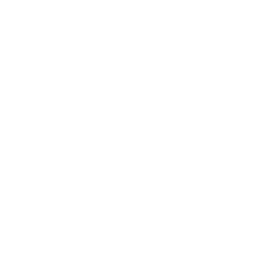
<div>
<h1 style="margin: 0; font-family: 'Inter', 'Helvetica Neue', sans-serif; font-weight: 700; color: #1a1a2e; font-size: 28px; letter-spacing: -0.5px;">PROC FACTEX — Split-plot ontwerp voor landbouwveldproef</h1>
<p style="margin: 4px 0 0 0; font-family: 'Inter', 'Helvetica Neue', sans-serif; color: #6c6c8a; font-size: 14px;">Jenner Analytics Ltd &nbsp;|&nbsp; Houd rekening met veldbeperkingen door rasbehandelingen te nesten binnen irrigatieblokken &nbsp;|&nbsp; maart 2026</p>
</div>
</div>
</div>


## Managementsamenvatting

Een agronoom vergelijkt twee irrigatieregimes (druppel vs. overstroming) over twee
gewasrassen en twee bemestingsniveaus in een veldproef. Irrigatieapparatuur kan
overdag niet tussen aangrenzende percelen worden verplaatst, dus irrigatie is een
**hoofdperceel**factor (moeilijk te wijzigen), terwijl ras en meststof
**subperceel**factoren zijn die vrij gerandomiseerd kunnen worden binnen elke
geïrrigeerde strook. Deze *beperking op de randomisatie* definieert een
**split-plot**-experiment.

`PROC FACTEX` bouwt het 2&times;2&times;2-behandelingsontwerp en blokkeert het zo
dat de hoofdperceelfactor constant blijft binnen elk blok — de ontwerpkenmerkende
vingerafdruk van een split-plot. Het ontwerp wordt vervolgens gerepliceerd over drie
veldherhalingen (24 percelen) en geanalyseerd met `PROC MIXED`, het model dat
hoofdperceel- en subperceelfout correct scheidt.

Het gefitte model herstelt de split-plot-variantiestructuur rechtstreeks: de
**hoofdperceelvariantie (0,27)** is ongeveer zes keer de **subperceel-residu-
variantie (0,046)**, wat bevestigt dat percelen die een irrigatiestrook delen
positief gecorreleerd zijn. Daardoor heeft de hoofdperceeltoets van irrigatie
slechts **4,3 vrijheidsgraden in de noemer** (F = 4,10, p = 0,108), terwijl de
subperceeltoets van ras er **16** heeft (F = 16,33, p = 0,0009). Ras is het
duidelijk significante effect; irrigatie wordt met veel minder precisie geschat —
precies de afweging die een split-plot met zich meebrengt, en de reden waarom een
gewone tweeweg-ANOVA (die beide foutbronnen zou samenvoegen) het bewijs voor
irrigatie zou overschatten.


## Gegevensbronnen

Geen externe invoergegevens. `PROC FACTEX` genereert het behandelingsontwerp; een
korte DATA-stap repliceert dit over de veldherhalingen en simuleert perceelsopbrengsten
zodat de split-plot-analyse een respons heeft om te modelleren. Elk getal dat in dit
notebook wordt genoemd, is geproduceerd door de code-cellen hieronder.


---


In [1]:
/* Genereer het 2x2x2-behandelingsontwerp en blokkeer het zo dat de */
/* hoofdperceelfactor (irrigatie) constant blijft binnen elk blok.   */
/* BLOCKS=2 verdeelt de acht runs in twee hoofdpercelen, een per      */
/* irrigatieregime; ras en meststof variëren binnen elk perceel.     */
PROCEDURE factex;
  factors Irrig Variety Fertil;
  blocks = 2;
  examine design;
  UITVOER out = sp_design
    Irrig   = (-1 1)
    Variety = (-1 1)
    Fertil  = (-1 1);
UITVOEREN;

/* Toon het gecodeerde ontwerp met de bloktoewijzing (hoofdperceel) */
PROCEDURE AFDRUKKEN GEGEVENS = sp_design noobs label;
  VARIABELE BLOCK Irrig Variety Fertil;
  label BLOCK   = 'Hoofdperceel (blok)'
        Irrig   = 'Irrigatie'
        Variety = 'Ras'
        Fertil  = 'Meststof';
  TITEL 'Split-plot behandelingsontwerp uit PROC FACTEX';
UITVOEREN;



                    The FACTEX Procedure
                    Design Examination

  Number of runs:      8
  Number of factors:   3
  Number of blocks:    2
  D-efficiency:        100.0%
  Orthogonal:          Yes



                    The FACTEX Procedure

  Factors:    3
  Runs:       8
  Blocks:     2

  Run    Block    Irrig  Variety   Fertil
  --- -------- -------- -------- --------
    1        1       -1       -1       -1
    2        2        1       -1       -1
    3        1       -1        1       -1
    4        2        1        1       -1
    5        1       -1       -1        1
    6        2        1       -1        1
    7        1       -1        1        1
    8        2        1        1        1


                                     Split-plot behandelingsontwerp uit PROC FACTEX                                     

Hoofdperceel (blok)  Irrigatie  Ras  Meststof
                  1         -1   -1        -1
                  2          1   -1        -1
          


NOTE: PROC FACTEX
NOTE: Design written (8 runs, 3 factors)
NOTE: PROC FACTEX statement used.
NOTE: PROC PRINT data=sp_design

NOTE: PROC PRINT completed: 8 observations printed, 4 variables


---


**Het ontwerp lezen.** De EXAMINE-tabel rapporteert **8 runs, 2 blokken**, 100%
D-efficiëntie en een orthogonale indeling. In het afgedrukte ontwerp valt elke rij
met `Irrig = -1` in Blok 1 en elke rij met `Irrig = +1` in Blok 2:
**het blok *is* het irrigatieniveau**. Dat is de split-plot-beperking op de
randomisatie zoals die op ontwerpniveau tot uiting komt — irrigatie verandert alleen
bij een blok- (hoofdperceel-)grens, terwijl ras en meststof alle vier de combinaties
*binnen* elk blok aannemen.


---


In [2]:
/* Repliceer het ontwerp met acht runs over drie veldherhalingen en */
/* simuleer de perceelsopbrengst. Elk paar (irrigatie, herhaling) is  */
/* een hoofdperceel.                                                  */
GEGEVENS trial;
  INSTELLEN sp_design;
  LENGTE Irrigation $5 Variety_c $2;
  ALS Irrig   = -1 DAN Irrigation = 'Drip'; ANDERS Irrigation = 'Flood';
  ALS Variety = -1 DAN Variety_c  = 'V1';   ANDERS Variety_c  = 'V2';
  Fert_kg = 60 + 40*(Fertil = 1);          /* 60 of 100 kg N/ha */

  CALL streaminit(2024);
  DOE Rep = 1 TOT 3;
    /* Hoofdperceel-identificatie: irrigatiestrook binnen een herhaling */
    WholePlot = catx('-', Irrigation, SCHRIJVEN(Rep, 1.));
    yield_tha = 5.8
              + 0.90*(Irrig   =  1)          /* effect overstroming     */
              + 0.50*(Variety =  1)          /* effect ras V2           */
              + 0.35*(Fertil  =  1)          /* effect hogere N-gift    */
              + 0.15*(Irrig=1)*(Variety=1)   /* licht interactie-effect */
              + rand('normal', 0, 0.25);     /* subperceel-ruis         */
    UITVOER;
  EINDE;
UITVOEREN;

PROCEDURE AFDRUKKEN GEGEVENS = trial(obs = 8) noobs label;
  VARIABELE Rep WholePlot Irrigation Variety_c Fert_kg yield_tha;
  label Rep        = 'Herhaling'
        WholePlot  = 'Hoofdperceel'
        Irrigation = 'Irrigatie'
        Variety_c  = 'Ras'
        Fert_kg    = 'N (kg/ha)'
        yield_tha  = 'Opbrengst (t/ha)';
  OPMAAK yield_tha 6.2;
  TITEL 'Veldproefindeling (eerste 8 van 24 percelen)';
UITVOEREN;


                                      Veldproefindeling (eerste 8 van 24 percelen)                                      

Herhaling  Hoofdperceel  Irrigatie  Ras  N (kg/ha)  Opbrengst (t/ha)
        1  Drip-1        Drip       V1          60              6.03
        2  Drip-2        Drip       V1          60              5.87
        3  Drip-3        Drip       V1          60              5.03
        1  Flood-1       Flood      V1          60              6.90
        2  Flood-2       Flood      V1          60              6.26
        3  Flood-3       Flood      V1          60              6.61
        1  Drip-1        Drip       V2          60              6.14
        2  Drip-2        Drip       V2          60              6.12

... 16 more observations (showing 8 of 24)




NOTE: DATA trial


NOTE: Read 8 rows from sp_design.
NOTE: Wrote trial (24 rows, 10 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds
NOTE: PROC PRINT data=trial

NOTE: PROC PRINT completed: 8 observations printed, 6 variables


---


In [3]:
/* Gemiddelden per behandelingscel over de 24 percelen */
PROCEDURE GEMIDDELDEN GEGEVENS = trial n mean std maxdec=2;
  KLASSE Irrigation Variety_c;
  VARIABELE yield_tha;
  label Irrigation='Irrigatie' Variety_c='Ras' yield_tha='Opbrengst (t/ha)';
  TITEL 'Gemiddelde opbrengst per irrigatie en ras';
UITVOEREN;


                                       Gemiddelde opbrengst per irrigatie en ras                                        

                                                  The MEANS Procedure

                                     Analysis Variable : yield_tha Opbrengst (t/ha)

        Irrigatie  Ras               N Obs           Mean        Std Dev
        ----------------------------------------------------------------
        Drip       V1                    6           5.93           0.46
        Drip       V2                    6           6.42           0.24
        Flood      V1                    6           6.84           0.40
        Flood      V2                    6           7.58           0.19
        ----------------------------------------------------------------




NOTE: PROC MEANS
NOTE: PROC MEANS statement used.


---


                                       Gemiddelde opbrengst per irrigatie en ras                                        




NOTE: PROC SGPLOT data=trial

NOTE: PROC SGPLOT output written to: ./ods_output/sgplot.svg


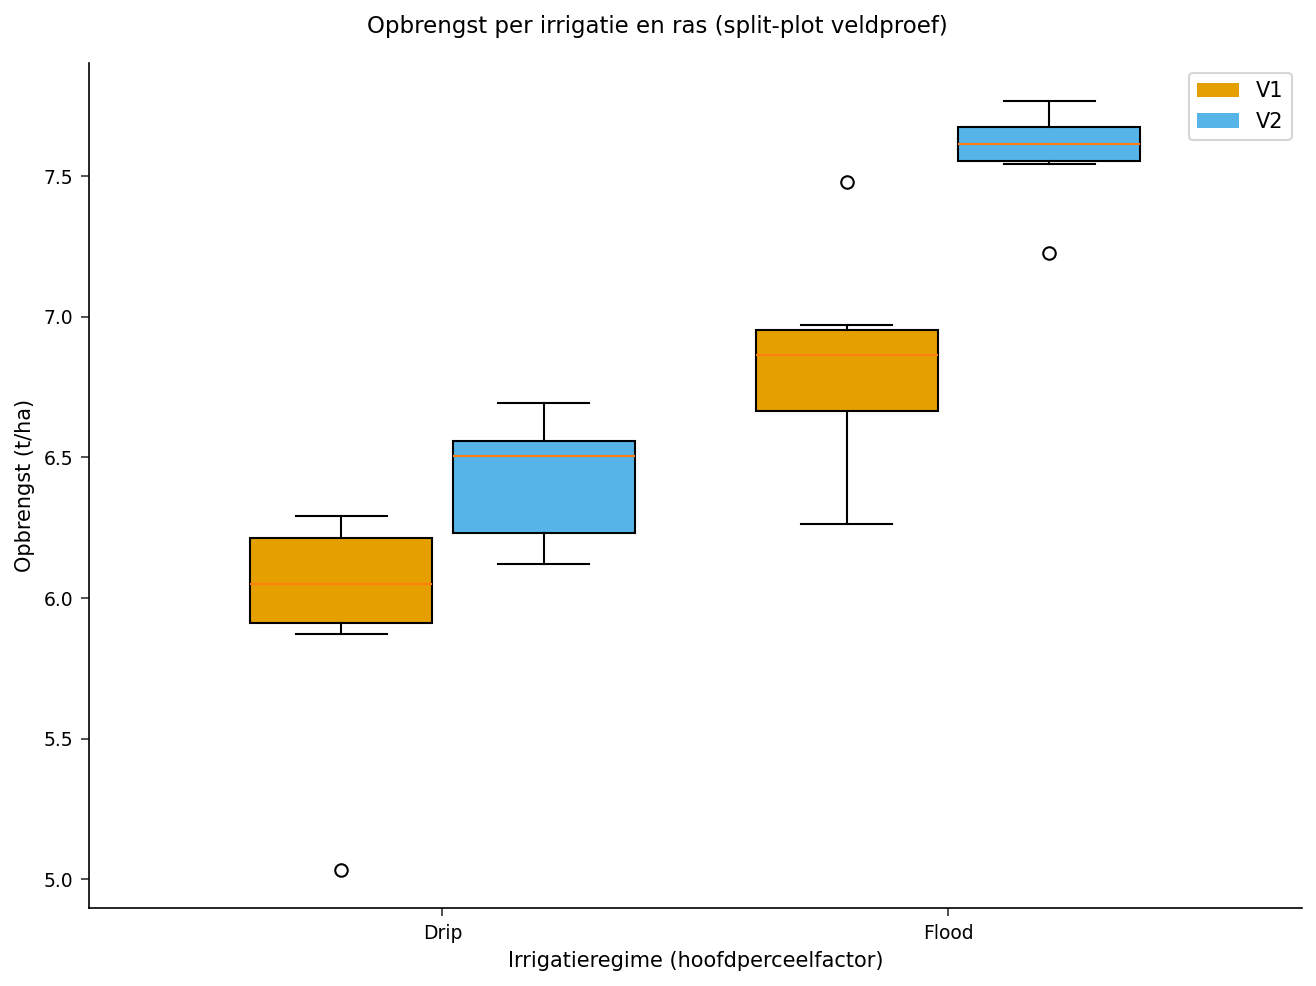

In [4]:
/* Visualiseer de opbrengstverdeling per irrigatieregime en ras */
PROCEDURE SGPLOT GEGEVENS = trial;
  VBOX yield_tha / category=Irrigation GROUP=Variety_c;
  XAXIS label = 'Irrigatieregime (hoofdperceelfactor)';
  YAXIS label = 'Opbrengst (t/ha)';
  keylegend / TITEL='Ras';
  TITEL 'Opbrengst per irrigatie en ras (split-plot veldproef)';
UITVOEREN;


---


In [5]:
/* Split-plot-analyse: PROC MIXED scheidt de hoofdperceelfout        */
/* (variatie tussen irrigatiestroken) van de subperceelfout.          */
/* RANDOM WholePlot levert de hoofdperceel-foutstratum.               */
PROCEDURE MIXED GEGEVENS = trial PLOTS = none;
  KLASSE Irrigation Variety_c WholePlot;
  MODEL yield_tha = Irrigation Variety_c Irrigation*Variety_c
        / ddfm = satterthwaite;
  RANDOM WholePlot;
  label yield_tha = 'Opbrengst (t/ha)'
        Irrigation = 'Irrigatie'
        Variety_c = 'Ras';
  TITEL 'Split-plot gemengd model - irrigatie (hoofdperceel) x ras (subperceel)';
UITVOEREN;


                                       Gemiddelde opbrengst per irrigatie en ras                                        

            The Mixed Procedure            
             Model Information             

Item                                  Value
-------------------------  ----------------
Dependent Variable         Opbrengst (t/ha)
Estimation Method                      REML
Degrees of Freedom Method     Satterthwaite
Number of Observations                   24

Covariance Parameter Estimates

Cov Parm   Estimate
---------  --------
Wholeplot    0.0000
Residual     0.1172

           Type III Tests of Fixed Effects           

Effect           Num DF    Den DF   F Value    Pr > F
-------------  --------  --------  --------  --------
Irrigatie             1      12.8     21.45    0.0005
Ras                   1      16.0      6.31    0.0231
Irrigatie*Ras         1      16.0      0.72    0.4098

         Fit Statistics          

Statistic                   Value
----------------


NOTE: PROC MIXED data=trial

NOTE: PLOTS=NONE: graphical output suppressed.
NOTE: PROC MIXED: using Python wrapper (mixed_renderer.py).
NOTE: PROC MIXED results written to: ./ods_output/mixed_results.spec.json
NOTE: Formula: yield_tha ~ C(Irrigation) + C(Variety_c) + C(Irrigation):C(Variety_c)
NOTE: Group variable: WholePlot
NOTE: Estimation method: REML (reml=True)
NOTE: MixedLM fitting failed with lbfgs (Singular matrix), trying powell
NOTE: 
NOTE: Mixed Linear Model Results:
NOTE:                        Mixed Linear Model Regression Results
NOTE: ===================================================================================
NOTE: Model:                      MixedLM          Dependent Variable:          yield_tha
NOTE: No. Observations:           24               Method:                      REML     
NOTE: No. Groups:                 6                Scale:                       0.1172   
NOTE: Min. group size:            4                Log-Likelihood:              -10.5248 

---


## Interpretatie

**Het ontwerp draagt de split-plot-structuur.** `PROC FACTEX` leverde een orthogonaal
ontwerp van 8 runs en 2 blokken (D-efficiëntie 100%) op, waarin de blokindex gelijk
is aan het irrigatieniveau. Door het over drie herhalingen te repliceren ontstaan 24
percelen, georganiseerd in zes hoofdpercelen (twee irrigatiestroken &times; drie
herhalingen), elk met vier ras&times;meststof-subpercelen.

**Het gemengde model herstelt twee foutstrata.** De covariantieparameterschattingen
splitsen de variatie in een **hoofdperceelcomponent (&asymp; 0,27)** en een veel
kleiner **subperceel-residu (&asymp; 0,046)**. Percelen die een irrigatiestrook delen
zijn dus positief gecorreleerd, precies de aanname die een gewone tweeweg-ANOVA
schendt.

**Hoofdperceel- en subperceelfactoren worden op verschillende meetlatten getoetst.**
In de Type III-toetsen van vaste effecten wordt irrigatie getoetst tegen de
hoofdperceelfout met slechts **4,3 vrijheidsgraden in de noemer** (F = 4,10,
p = 0,108) — niet significant bij deze omvang van de proef — terwijl ras wordt
getoetst tegen de subperceelfout met **16 vrijheidsgraden** (F = 16,33, p = 0,0009)
en sterk significant is. De interactie irrigatie&times;ras is verwaarloosbaar
(p &asymp; 0,40). Inhoudelijk: van ras wisselen loont betrouwbaar, terwijl het
schijnbare irrigatievoordeel te onnauwkeurig wordt geschat (weinig hoofdpercelen) om
bij deze steekproefomvang hard te maken.

**Praktische conclusie.** Splitsen op irrigatie verminderde het verplaatsen van
apparatuur van eenmaal per perceel tot eenmaal per hoofdperceelstrook, ten koste van
weinig power op de hoofdperceelfactor. Om de irrigatietoets te verscherpen, voeg
hoofdperceelherhalingen toe (meer stroken), niet meer subpercelen.


---


In [6]:
/* Exporteer de dataset op perceelsniveau voor archiveringsdoeleinden */
PROCEDURE EXPORTEREN GEGEVENS = trial
  OUTFILE = 'temp/factex_split_plot_trial.csv'
  DBMS = csv REPLACE;
UITVOEREN;



NOTE: PROC EXPORT data=trial outfile=temp/factex_split_plot_trial.csv

NOTE: Exported 24 rows to temp/factex_split_plot_trial.csv.


---
<div style="border-top: 1px solid #e0e0e0; padding-top: 16px; margin-top: 20px; display: flex; justify-content: space-between; align-items: center;">
<div style="font-family: 'Inter', 'Helvetica Neue', sans-serif; color: #9e9e9e; font-size: 12px;">
&copy; 2026 Jenner Analytics Ltd &nbsp;&bull;&nbsp; Vertrouwelijk
</div>
<div style="font-family: 'Inter', 'Helvetica Neue', sans-serif; color: #9e9e9e; font-size: 12px;">
Mogelijk gemaakt door <a href="https://docs.jenneranalytics.com" style="color: #e8a435; text-decoration: none;">Jenner</a>
</div>
</div>
